# Predicting the Price of Diamond
In this notebook, we will be predicting the price of diamond based on the given dataset. You can find the competition and the dataset [here](https://www.kaggle.com/competitions/predicting-the-price-of-diamond).

<div align="center">
<img src="https://www.kaggle.com/competitions/114463/images/header" />
</div>

## 1. Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import ExtraTreeRegressor, DecisionTreeRegressor
import lightgbm as lgb
import xgboost as xgb
from tqdm.notebook import tqdm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings

### Configurations

In [2]:
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('darkgrid')

## 2. Loading Data

In [3]:
df = pd.read_csv('train.csv', index_col='id')

In [4]:
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
id,,,,,,,,,,
0,0.31,Ideal,H,VS2,61.8,57.0,4.39,4.36,2.68,681.0
1,0.38,Ideal,G,VVS1,60.8,56.0,4.67,4.73,2.89,1132.0
2,0.38,Very Good,G,SI1,61.0,56.0,4.68,4.64,2.81,1307.0
3,0.71,Premium,H,SI1,60.6,58.0,5.83,5.80,3.49,1308.0
4,0.31,Very Good,G,IF,62.0,57.0,4.32,4.36,2.70,645.0


In [5]:
df.shape

(20000, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    20000 non-null  float64
 1   cut      20000 non-null  object 
 2   color    20000 non-null  object 
 3   clarity  20000 non-null  object 
 4   depth    20000 non-null  float64
 5   table    20000 non-null  float64
 6   x        20000 non-null  float64
 7   y        20000 non-null  float64
 8   z        20000 non-null  float64
 9   price    20000 non-null  float64
dtypes: float64(7), object(3)
memory usage: 1.7+ MB


In [7]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,20000.0,0.773143,0.434161,0.00,0.39,0.71,1.02,6.01
depth,20000.0,61.814170,1.058000,55.70,61.30,61.90,62.40,69.50
table,20000.0,57.245750,1.813067,52.00,56.00,57.00,58.00,68.00
x,20000.0,5.692152,1.145070,0.24,4.68,5.72,6.50,65.10
y,20000.0,5.696200,1.147782,0.26,4.69,5.73,6.50,67.50
z,20000.0,3.519596,0.659160,2.11,2.89,3.54,4.02,7.54
price,20000.0,3953.504850,4016.660252,327.00,963.00,2403.00,5330.25,18797.00


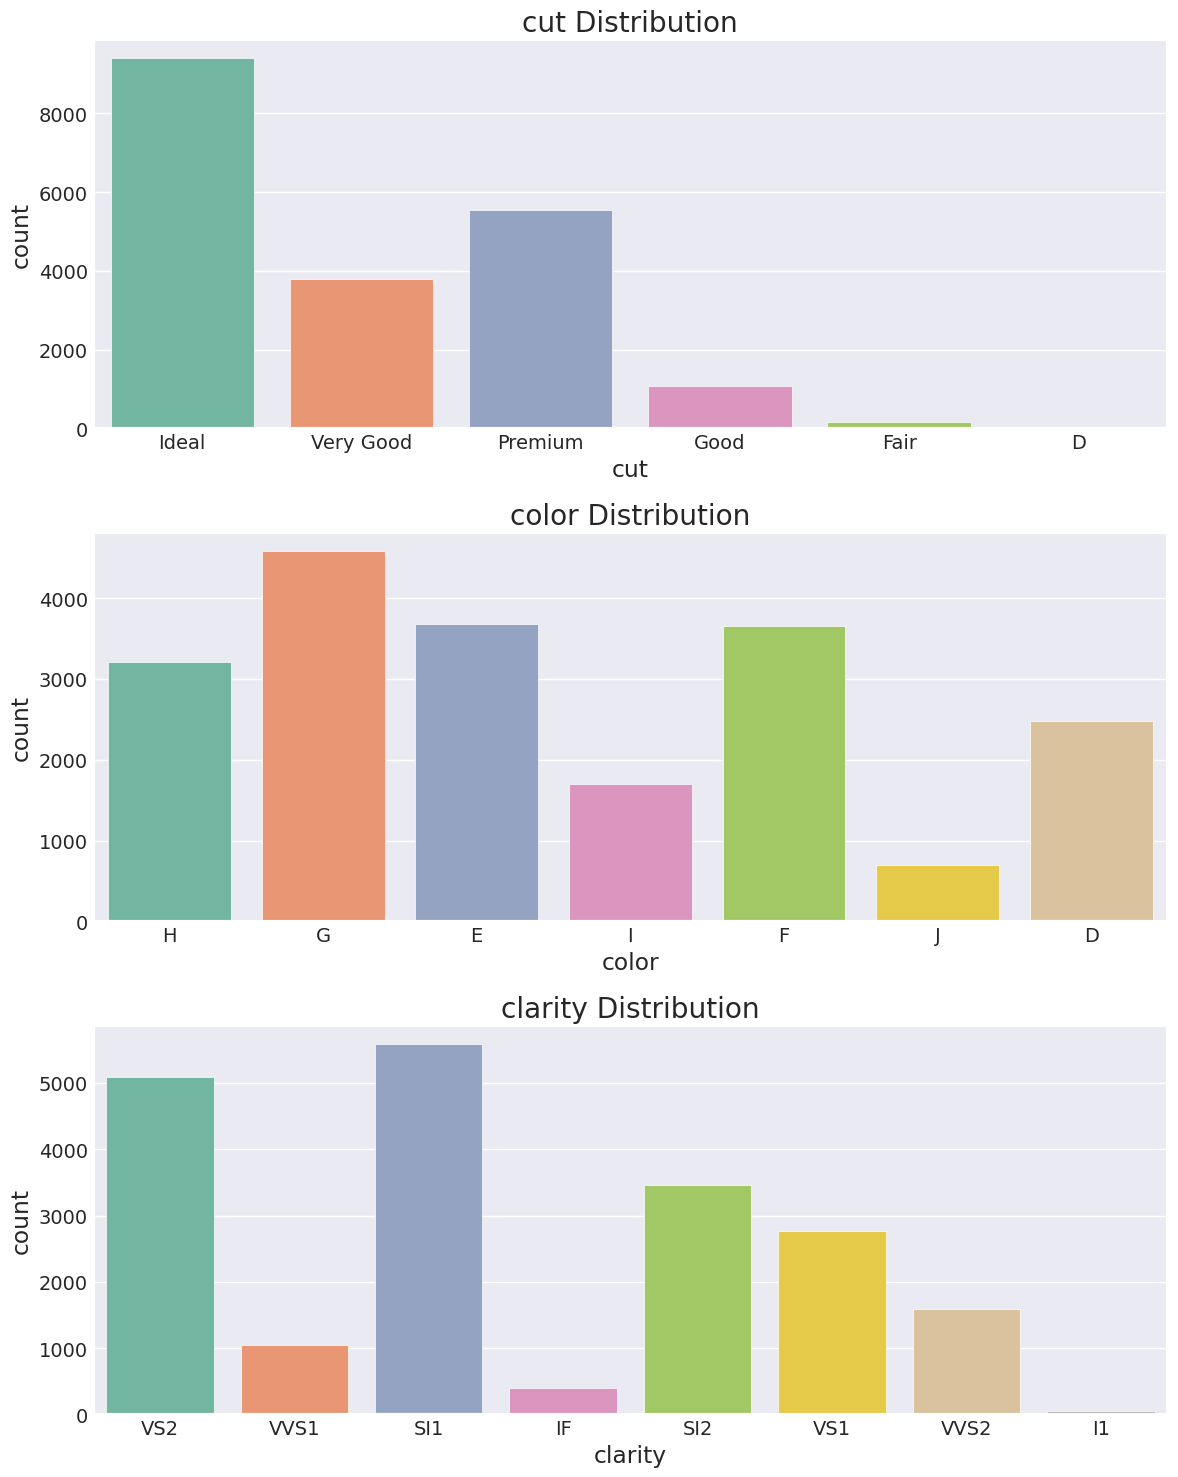

In [10]:
plt.figure(figsize=(12, 15))

for i, col in enumerate(df.select_dtypes(include=['object']).columns):
    plt.subplot(3, 1, i+1)
    sns.countplot(df, x=col, hue=col, palette='Set2')
    plt.title(f'{col} Distribution')
plt.tight_layout()

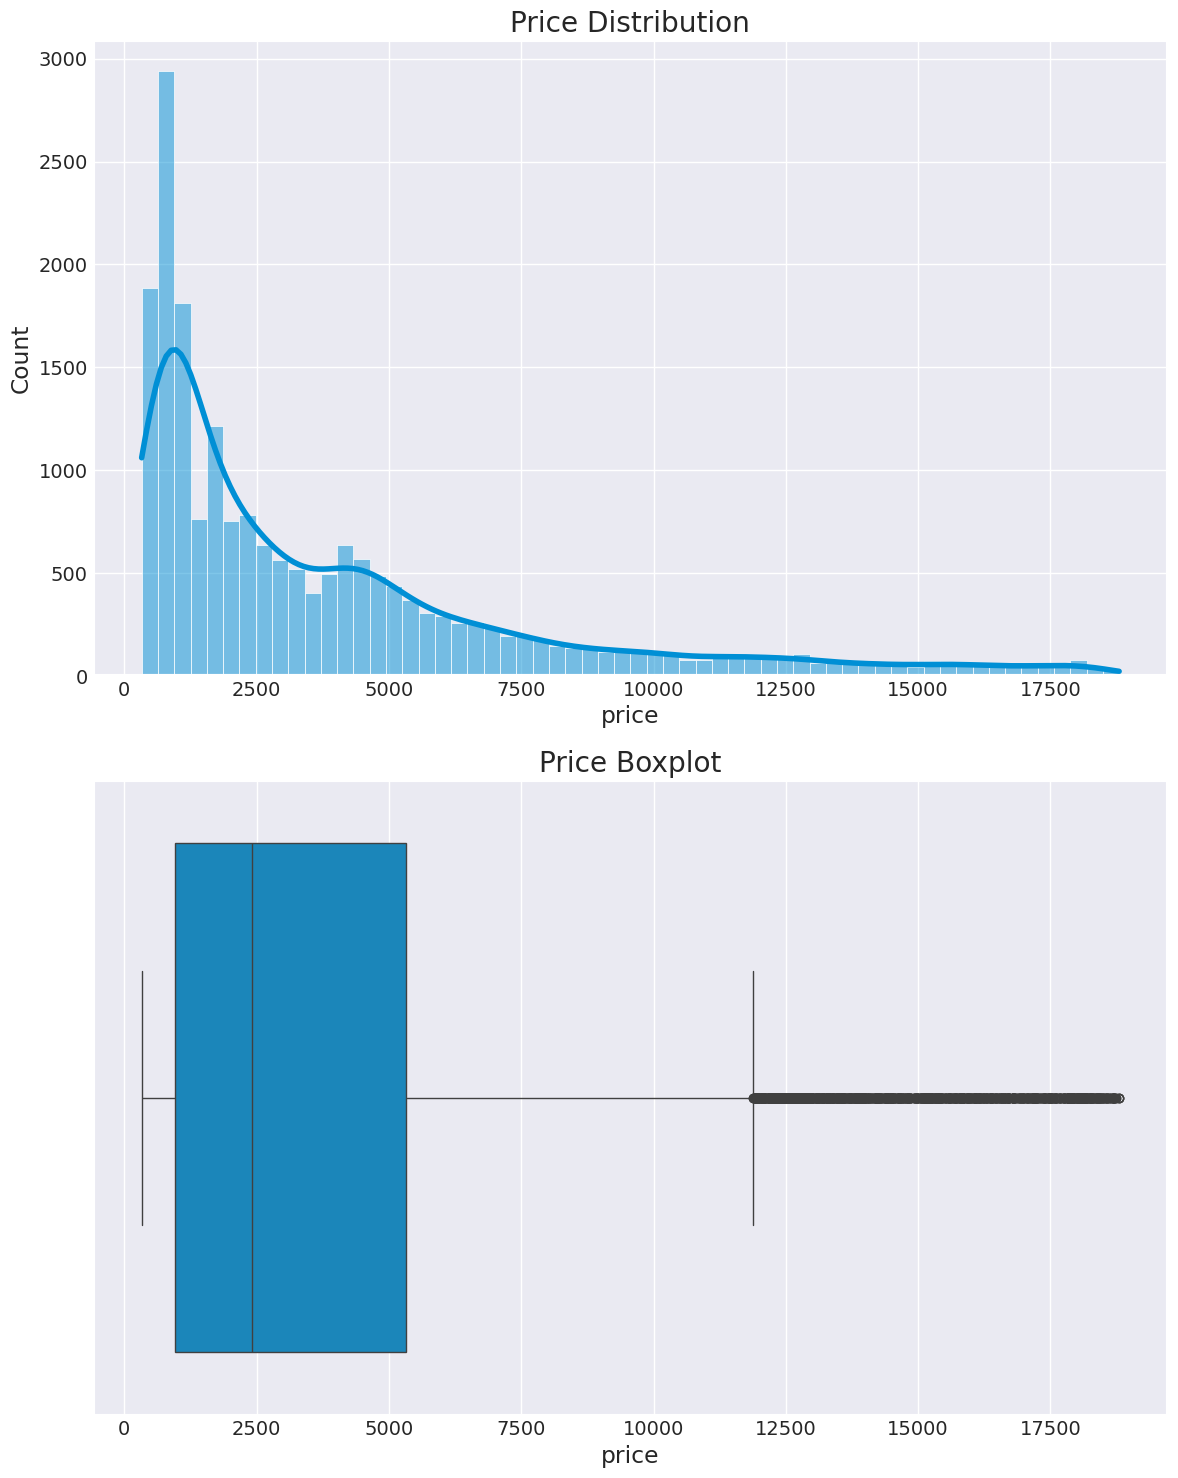

In [11]:
plt.figure(figsize=(12, 15))

plt.subplot(211)
sns.histplot(df, x='price', kde=True, bins=60)
plt.title('Price Distribution')

plt.subplot(212)
sns.boxplot(df['price'], orient='h')
plt.title('Price Boxplot')

plt.tight_layout()

In [12]:
px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    color='price',
    hover_data=['price'],
)

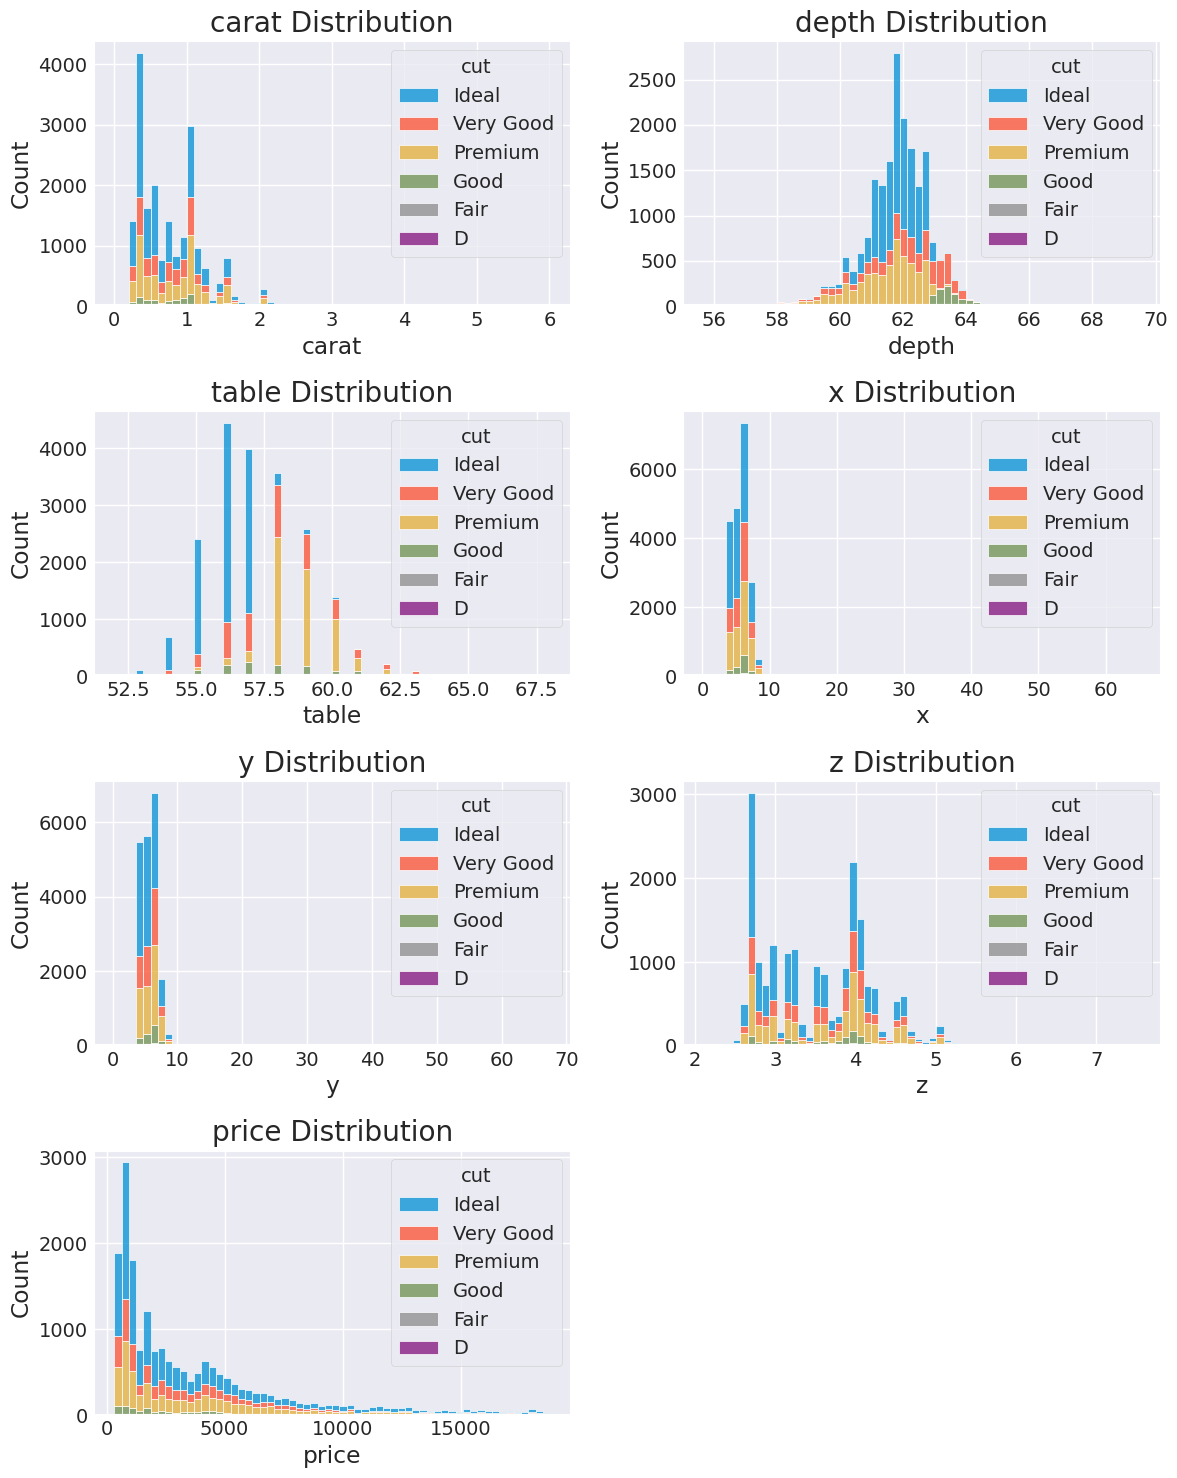

In [13]:
plt.figure(figsize=(12, 15))
for i, col in enumerate(df.select_dtypes(exclude=['object']).columns):
    plt.subplot(4, 2, i+1)
    sns.histplot(df, x=col, hue='cut', multiple='stack', bins=60)
    plt.title(f'{col} Distribution')
plt.tight_layout()

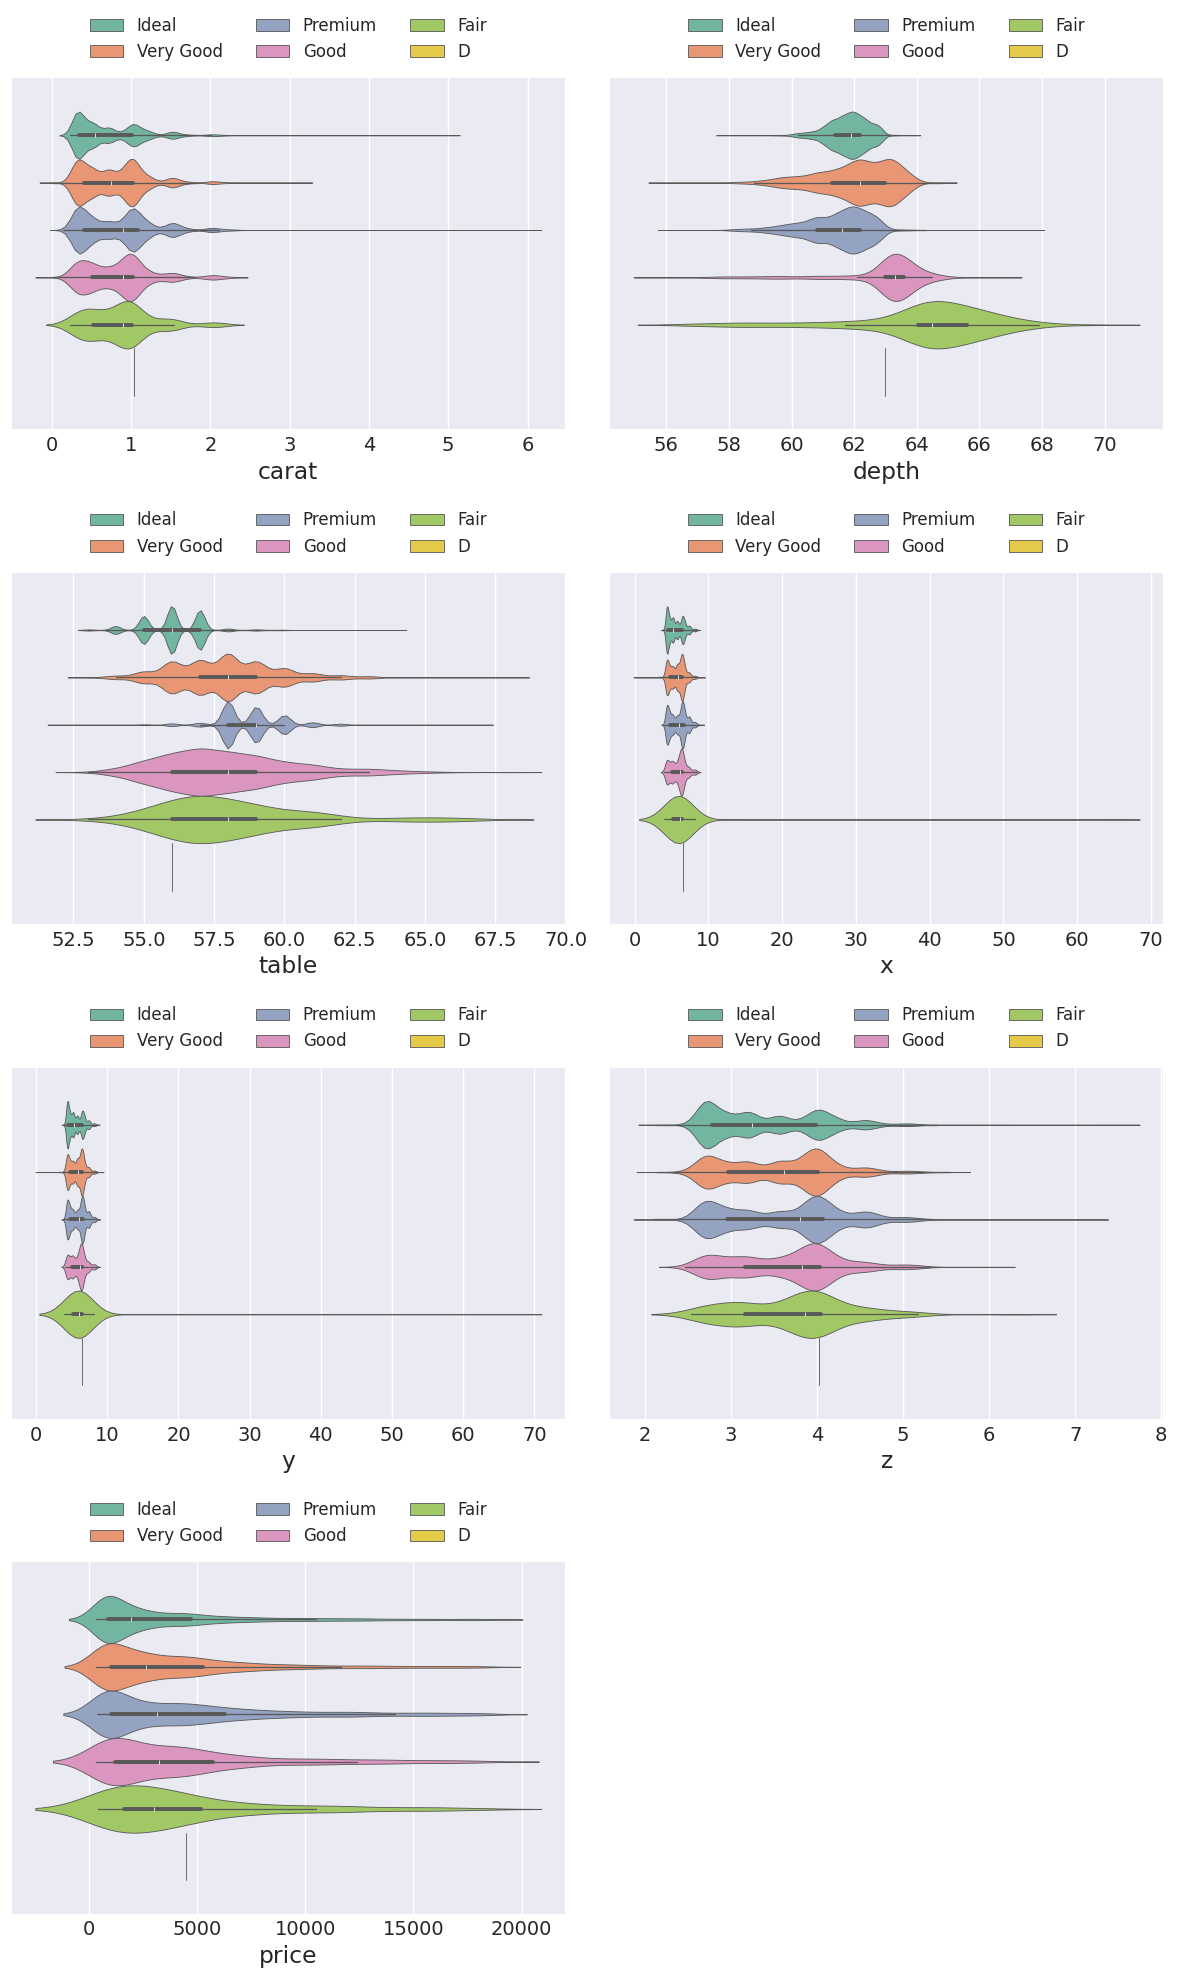

In [14]:
plt.figure(figsize=(12, 20))
for i, col in enumerate(df.select_dtypes(exclude=['object']).columns):
    plt.subplot(4, 2, i+1)
    ax = sns.violinplot(df, x=col, hue='cut', palette='Set2')
    sns.move_legend(
        ax, "lower center",
        bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
        fontsize=12
    )
plt.tight_layout()

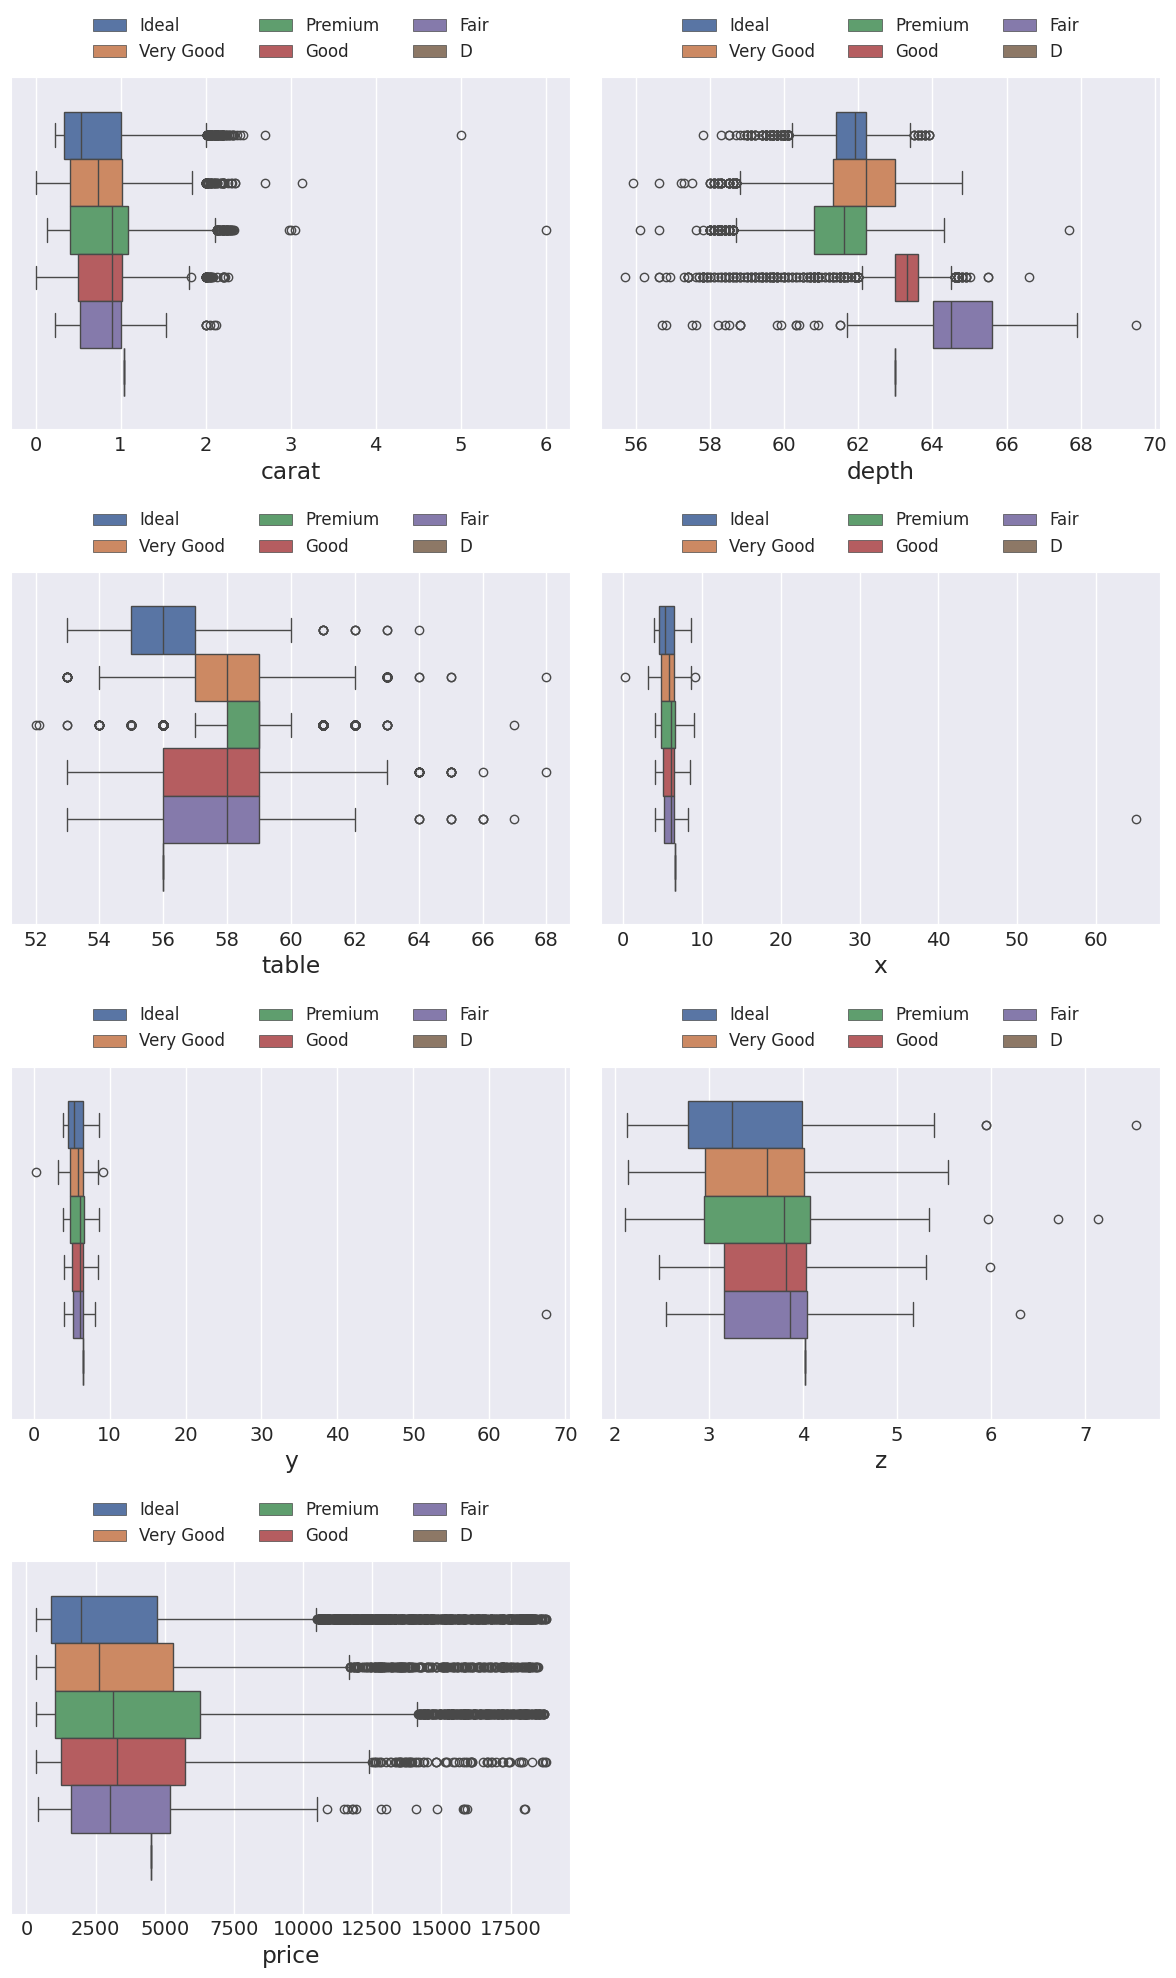

In [15]:
plt.figure(figsize=(12, 20))
for i, col in enumerate(df.select_dtypes(exclude=['object']).columns):
    plt.subplot(4, 2, i+1)
    ax = sns.boxplot(df, x=col, hue='cut', palette='deep')
    sns.move_legend(
        ax, "lower center",
        bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
        fontsize=12
    )
plt.tight_layout()

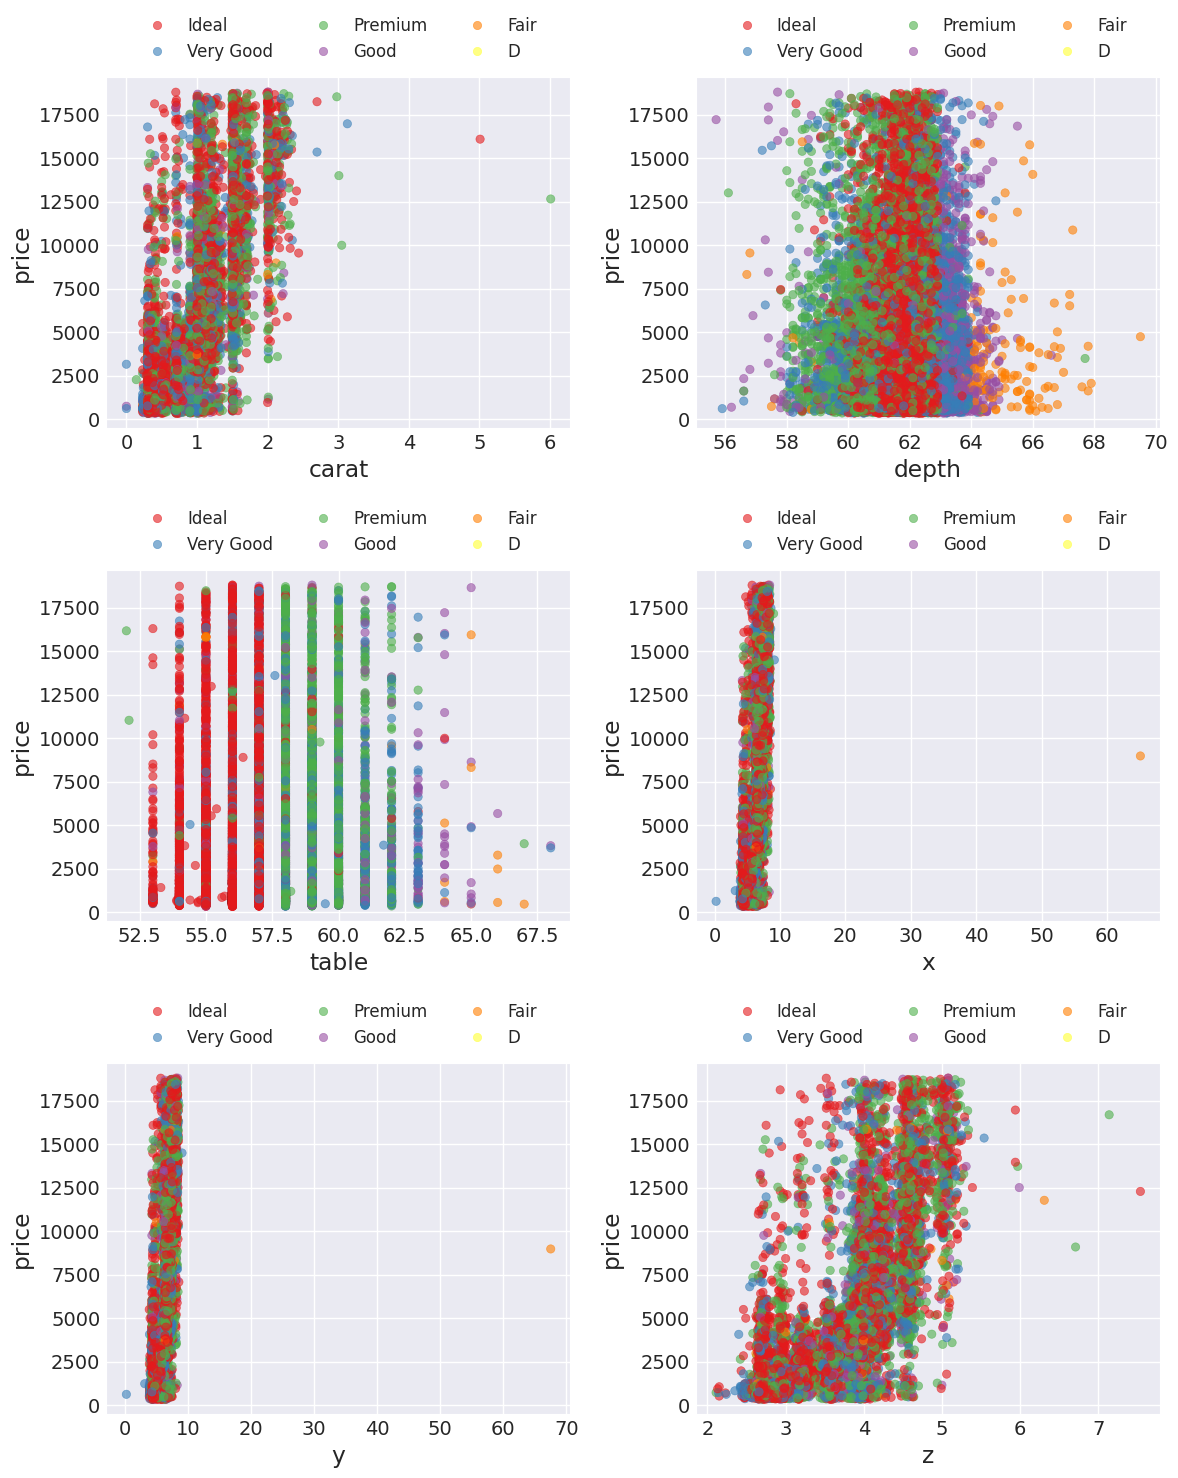

In [16]:
plt.figure(figsize=(12, 15))
for i, col in enumerate(df.select_dtypes(exclude=['object']).columns[:-1]):
    plt.subplot(3, 2, i+1)
    ax = sns.scatterplot(
        df,
        x=col,
        y='price',
        hue='cut',
        palette='Set1',
        edgecolor=None,
        alpha=0.6
    )
    sns.move_legend(
        ax, "lower center",
        bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
        fontsize=12
    )
plt.tight_layout()

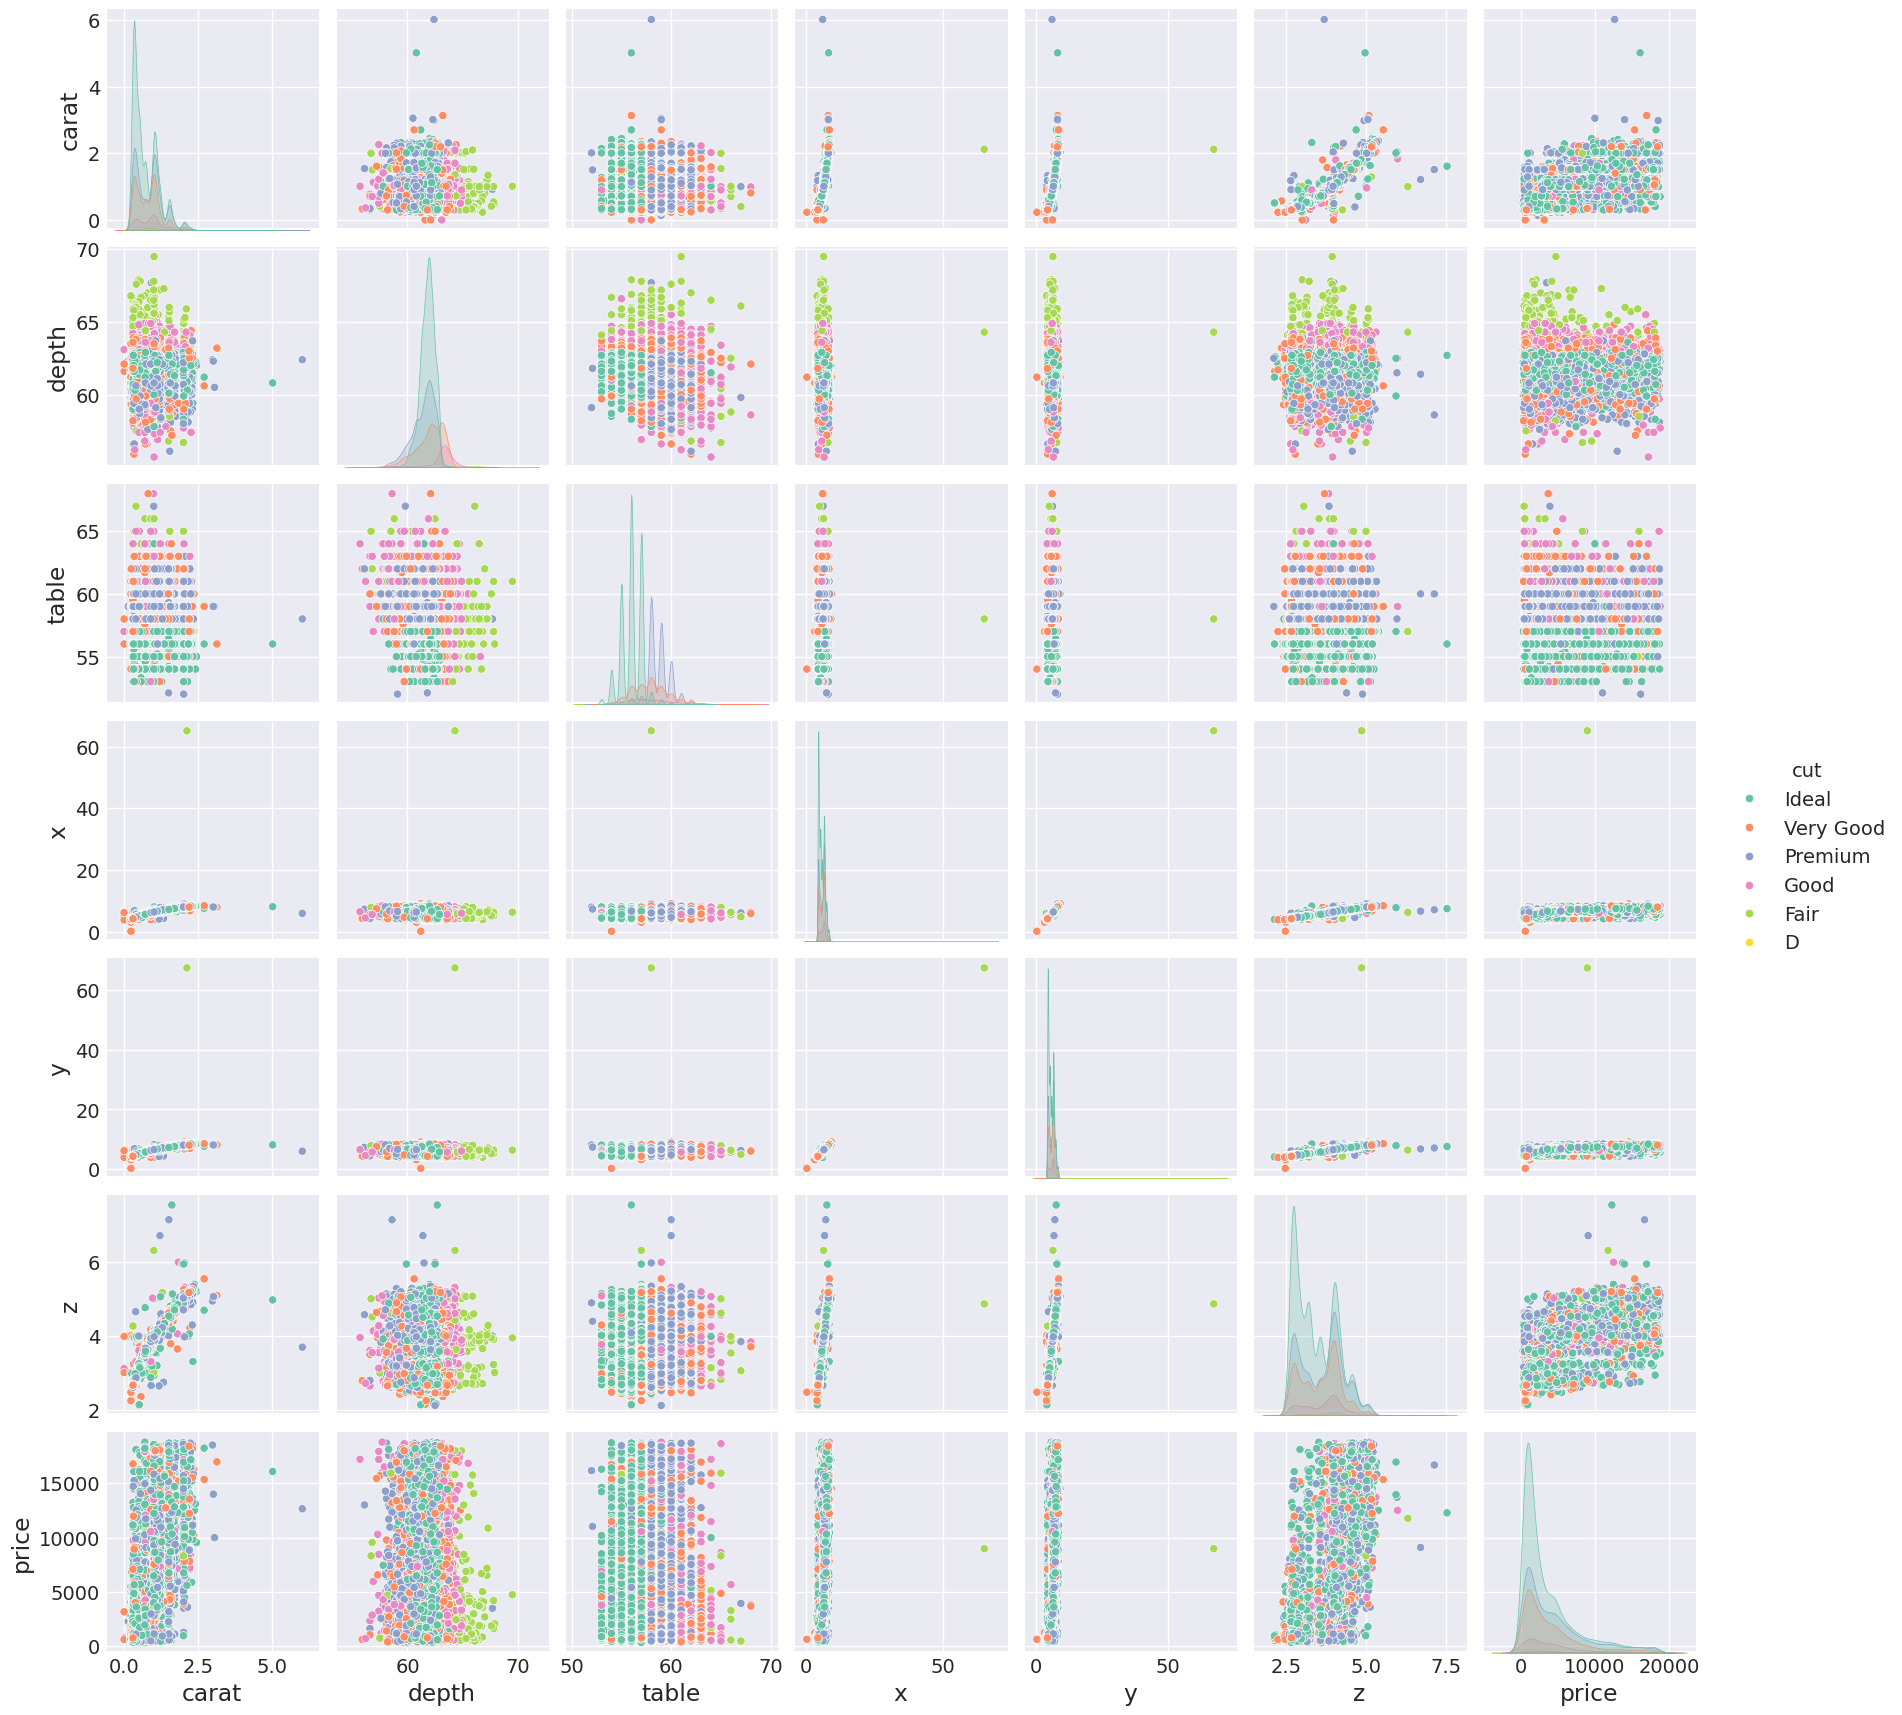

In [17]:
sns.pairplot(df, hue='cut', palette='Set2');

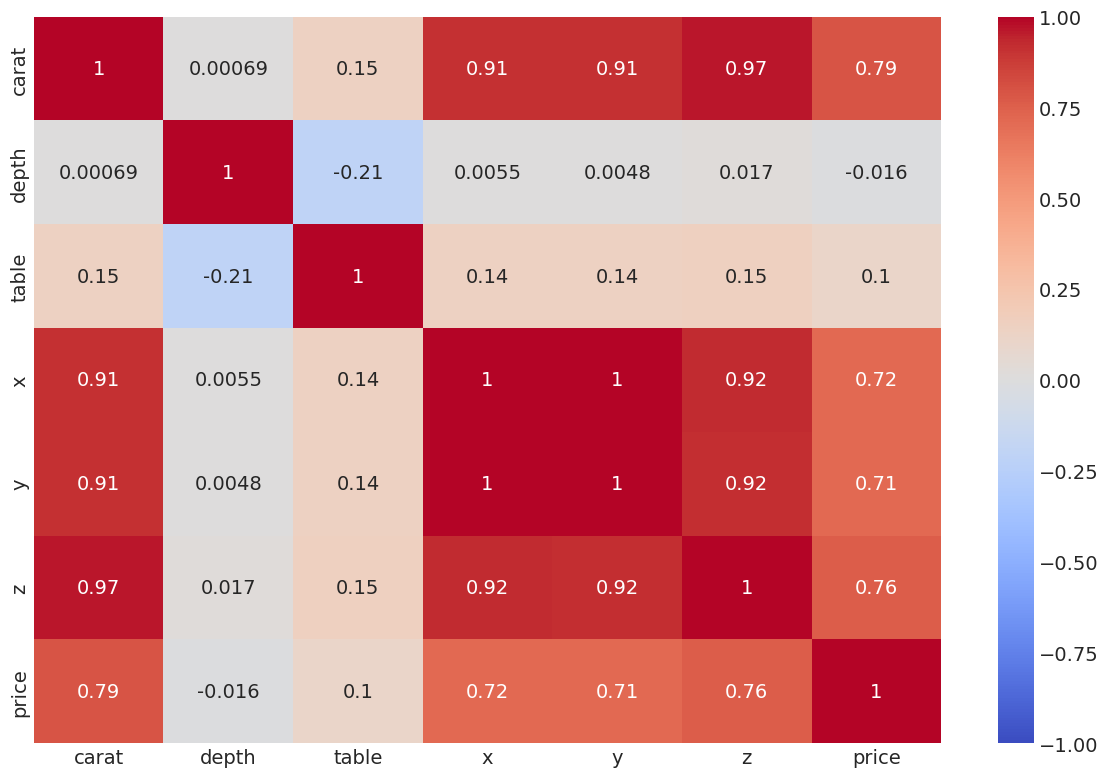

In [18]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
)
plt.tight_layout()

In [19]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price    1.000000
carat    0.792882
z        0.762594
x        0.716429
y        0.711988
table    0.103977
depth   -0.015520
Name: price, dtype: float64

In [20]:
df.cut.value_counts()

cut
Ideal        9408
Premium      5554
Very Good    3790
Good         1081
Fair          166
D               1
Name: count, dtype: int64

In [21]:
df = df[df['cut'] != 'D']

## 4. Data Preprocessing

In [22]:
x = df.drop(columns=['price', 'depth'])
y = df['price']

In [23]:
x_dummies = pd.get_dummies(x)

In [24]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_dummies)

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

## 5. Model Training

In [26]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "ExtraTreeRegressor": ExtraTreeRegressor(),
    "LightGBM": lgb.LGBMRegressor(verbose=-1),
    "XGBoost": xgb.XGBRegressor()
}

def evaluate(x_train, y_train, x_test, y_test):
    results = []
    for name, model in tqdm(models.items()):
        print(f"Training {name} model...")
        y_pred = model.fit(x_train, y_train).predict(x_test)
        
        results.append({
            "Model": name,
            "R2_Score": r2_score(y_test, y_pred),
            "MSE": mean_squared_error(y_test, y_pred),
            "RMSE": mean_squared_error(y_test, y_pred)**0.5
        })
    report = pd.DataFrame(results).sort_values('R2_Score', ascending=False)
    report.reset_index(drop=True, inplace=True)
    return report

In [27]:
evaluate(x_train, y_train, x_test, y_test)

  0%|          | 0/7 [00:00<?, ?it/s]

Training LinearRegression model...
Training Ridge model...
Training Lasso model...
Training DecisionTreeRegressor model...
Training ExtraTreeRegressor model...
Training LightGBM model...
Training XGBoost model...


,Model,R2_Score,MSE,RMSE
0,LightGBM,0.656694,5.858767e+06,2420.488917
1,Lasso,0.635098,6.227318e+06,2495.459572
2,LinearRegression,0.634970,6.229497e+06,2495.895950
3,Ridge,0.634909,6.230545e+06,2496.106018
4,XGBoost,0.629671,6.319933e+06,2513.947700
5,ExtraTreeRegressor,0.287296,1.216281e+07,3487.522553
6,DecisionTreeRegressor,0.264188,1.255717e+07,3543.610208


## 6. Building the Pipeline, Saving the Model, Making Submission

In [28]:
test_df = pd.read_csv('test.csv', index_col='id')
test_df.drop(columns=['depth'], inplace=True)

In [29]:
data = pd.concat([df, test_df], axis=0)

In [30]:
encoder = OrdinalEncoder()
encoder.fit(data[['cut', 'clarity', 'color']])

,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [31]:
data[['cut', 'clarity', 'color']] = encoder.transform(data[['cut', 'clarity', 'color']])

In [32]:
x = data[data.price.notna()]
test = data[data.price.isna()]

In [34]:
test.drop(columns=['price', 'depth'], inplace=True)

y = x['price']
x.drop(columns=['price', 'depth'], inplace=True)

In [35]:
preprocessor = ColumnTransformer([
    ('scaler', MinMaxScaler(), ['carat', 'table', 'x', 'y', 'z'])
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMRegressor(verbose=-1, random_state=42))
])
pipeline.fit(x, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [59]:
x

,carat,cut,color,clarity,table,x,y,z
id,,,,,,,,
0,0.31,2.0,4.0,7.0,57.0,4.39,4.36,2.68
1,0.38,2.0,3.0,9.0,56.0,4.67,4.73,2.89
2,0.38,4.0,3.0,3.0,56.0,4.68,4.64,2.81
3,0.71,3.0,4.0,3.0,58.0,5.83,5.80,3.49
4,0.31,4.0,3.0,2.0,57.0,4.32,4.36,2.70
...,...,...,...,...,...,...,...,...
19995,1.13,3.0,3.0,4.0,56.0,6.77,6.82,4.08
19996,0.91,3.0,3.0,6.0,59.0,6.26,6.30,3.93
19997,1.12,2.0,4.0,3.0,57.0,6.74,6.71,4.10


In [36]:
pipeline.score(x, y)

0.6978025636791549

In [ ]:
joblib.dump(pipeline, 'diamond_price_pipeline.pkl')
joblib.dump(encoder, 'diamond_categorical_encoder.pkl')

['diamond_categorical_encoder.pkl']

In [38]:
test_df = pd.read_csv('test.csv', index_col='id')
test_df.drop(columns=['depth'], inplace=True)

test_df[['cut', 'clarity', 'color']] = encoder.transform(test_df[['cut', 'clarity', 'color']])

predictions = pipeline.predict(test_df)
submission = pd.DataFrame({
    'id': test_df.index,
    'price': predictions
})
submission.head()

,id,price
0,20000,1799.583127
1,20001,3091.244932
2,20002,1047.968995
3,20003,1047.968995
4,20004,967.935768


In [39]:
submission.to_csv('submission.csv', index=False)

## 7. Conclusion
We built a machine learning pipeline to predict the price of diamond. We used the `LightGBM` model as the best model. We saved the pipeline for future use and used it to generate predictions for the test set.